# Next-Day Volatility Forecasting: Random Forest Lag Comparison

This notebook compares three Random Forest models per stock using different autoregressive lag depths:
- `lag1` model: uses `volatility_1D_lag1`
- `lag5` model: uses `volatility_1D_lag1` ... `volatility_1D_lag5`
- `lag21` model: uses `volatility_1D_lag1` ... `volatility_1D_lag21`

Stocks:
- `CTVA`
- `DDOG`

## Workflow Overview

1. Load and sort data
2. Apply the exact split logic provided
3. Filter to `CTVA` and `DDOG`
4. Create leakage-safe engineered features
5. Validation comparison:
   - Naive baseline (`today volatility -> next-day volatility`)
   - `RF_lag1`, `RF_lag5`, `RF_lag21`
6. Retrain on train+validation
7. Forecast unseen sequentially one day ahead (no daily refit)
8. Report metrics, tables, and plots

## Imports and Reproducibility

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed set to: {SEED}")

Seed set to: 42


## Paths and Global Configuration

In [2]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"
unseen_path = "data/sp500_unseen.csv"

symbols_to_model = ["CTVA", "DDOG"]
include_today = True
use_log_volatility = False

lag_options = [1, 5, 21]
n_lags_max = max(lag_options)

rf_n_estimators = 400
rf_max_depth = 8
rf_min_samples_leaf = 5

print("csv_path:", csv_path)
print("unseen_path:", unseen_path)
print("symbols:", symbols_to_model)
print("include_today:", include_today)
print("use_log_volatility:", use_log_volatility)
print("lag_options:", lag_options)
print("rf_n_estimators:", rf_n_estimators)
print("rf_max_depth:", rf_max_depth)
print("rf_min_samples_leaf:", rf_min_samples_leaf)

csv_path: data/sp500_5yr_with_sectors_weights.csv
unseen_path: data/sp500_unseen.csv
symbols: ['CTVA', 'DDOG']
include_today: True
use_log_volatility: False
lag_options: [1, 5, 21]
rf_n_estimators: 400
rf_max_depth: 8
rf_min_samples_leaf: 5


## Load Data and Inspect Raw Structure

In [3]:
df_initial = pd.read_csv(csv_path)
df_initial["Date"] = pd.to_datetime(df_initial["Date"])
df_initial = df_initial.sort_values(["Symbol", "Date"]).copy()

unseen_reference = pd.read_csv(unseen_path)
unseen_reference["Date"] = pd.to_datetime(unseen_reference["Date"])
unseen_reference = unseen_reference.sort_values(["Symbol", "Date"]).copy()

print("Main data shape:", df_initial.shape)
print("Unseen reference shape:", unseen_reference.shape)
print("\nMain columns:")
print(df_initial.columns.tolist())

Main data shape: (626169, 10)
Unseen reference shape: (125248, 10)

Main columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol', 'Security', 'Sector', 'Weight']


In [4]:
print("Main date range:", df_initial["Date"].min().date(), "to", df_initial["Date"].max().date())
print("Unseen reference date range:", unseen_reference["Date"].min().date(), "to", unseen_reference["Date"].max().date())
print("\nHead of main data:")
display(df_initial.head(3))

Main date range: 2021-03-22 to 2026-03-20
Unseen reference date range: 2025-03-21 to 2026-03-20

Head of main data:


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005


## Exact Date Split Logic (As Requested)

The following cell uses the split code exactly as provided.

In [5]:
df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).copy()

unseen_end = df['Date'].max().normalize()
unseen_start = unseen_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
val_end = unseen_start - pd.Timedelta(days=1)
val_start = val_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
train_end = val_start - pd.Timedelta(days=1)
data_start = train_end - pd.DateOffset(years=3) + pd.Timedelta(days=1)

print("data_start   :", data_start.date())
print("train_end    :", train_end.date())
print("val_start    :", val_start.date())
print("val_end      :", val_end.date())
print("unseen_start :", unseen_start.date())
print("unseen_end   :", unseen_end.date())

data_start   : 2021-03-21
train_end    : 2024-03-20
val_start    : 2024-03-21
val_end      : 2025-03-20
unseen_start : 2025-03-21
unseen_end   : 2026-03-20


## Filter to CTVA and DDOG

In [6]:
df = df[df["Symbol"].isin(symbols_to_model)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Filtered shape:", df.shape)
print("Symbols in filtered data:", sorted(df["Symbol"].unique()))

display(
    df.groupby("Symbol")
      .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
      .reset_index()
)

Filtered shape: (2512, 10)
Symbols in filtered data: ['CTVA', 'DDOG']


,Symbol,rows,min_date,max_date
0,CTVA,1256,2021-03-22,2026-03-20
1,DDOG,1256,2021-03-22,2026-03-20


In [7]:
unseen_reference_small = unseen_reference[unseen_reference["Symbol"].isin(symbols_to_model)].copy()
print("Filtered unseen reference shape:", unseen_reference_small.shape)

display(
    unseen_reference_small.groupby("Symbol")
    .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
    .reset_index()
)

Filtered unseen reference shape: (502, 10)


,Symbol,rows,min_date,max_date
0,CTVA,251,2025-03-21,2026-03-20
1,DDOG,251,2025-03-21,2026-03-20


## Leakage-Safe Stage Separation

We isolate unseen data first, and model development uses only pre-unseen data.

In [8]:
pre_unseen_raw = df[(df["Date"] >= data_start) & (df["Date"] <= val_end)].copy()
unseen_raw_from_split = df[(df["Date"] >= unseen_start) & (df["Date"] <= unseen_end)].copy()
unseen_raw = unseen_reference_small[
    (unseen_reference_small["Date"] >= unseen_start) & (unseen_reference_small["Date"] <= unseen_end)
].copy()

print("pre_unseen_raw shape:", pre_unseen_raw.shape)
print("unseen_raw_from_split shape:", unseen_raw_from_split.shape)
print("unseen_raw (from unseen_path) shape:", unseen_raw.shape)

print("\npre_unseen date range:", pre_unseen_raw["Date"].min().date(), "to", pre_unseen_raw["Date"].max().date())
print("unseen_from_split date range:", unseen_raw_from_split["Date"].min().date(), "to", unseen_raw_from_split["Date"].max().date())
print("unseen_from_file date range :", unseen_raw["Date"].min().date(), "to", unseen_raw["Date"].max().date())

pre_unseen_raw shape: (2010, 10)
unseen_raw_from_split shape: (502, 10)
unseen_raw (from unseen_path) shape: (502, 10)

pre_unseen date range: 2021-03-22 to 2025-03-20
unseen_from_split date range: 2025-03-21 to 2026-03-20
unseen_from_file date range : 2025-03-21 to 2026-03-20


## Feature Engineering Functions

In [9]:
def create_engineered_features(
    input_df: pd.DataFrame,
    include_today: bool = True,
    use_log_volatility: bool = False,
    n_lags: int = 21
) -> pd.DataFrame:
    out_frames = []

    for symbol, g in input_df.sort_values(["Symbol", "Date"]).groupby("Symbol", sort=False):
        g = g.copy()
        g["Close"] = g["Close"].astype(float)
        g["Volume"] = g["Volume"].astype(float)

        g["log_return_1D"] = np.log(g["Close"]).diff()
        g["volatility_1D"] = g["log_return_1D"].abs()
        if use_log_volatility:
            g["volatility_1D"] = np.log1p(g["volatility_1D"])

        log_volume = np.log(g["Volume"].replace(0, np.nan))
        g["volume_change_1D"] = log_volume.diff()

        g["log_return_5D"] = g["log_return_1D"].rolling(5, min_periods=5).sum()
        g["log_return_21D"] = g["log_return_1D"].rolling(21, min_periods=21).sum()

        g["volatility_5D"] = g["log_return_1D"].rolling(5, min_periods=5).std()
        g["volatility_21D"] = g["log_return_1D"].rolling(21, min_periods=21).std()

        g["volume_change_5D"] = g["volume_change_1D"].rolling(5, min_periods=5).sum()
        g["volume_change_21D"] = g["volume_change_1D"].rolling(21, min_periods=21).sum()

        lag_shift_base = 0 if include_today else 1
        for lag in range(1, n_lags + 1):
            g[f"volatility_1D_lag{lag}"] = g["volatility_1D"].shift(lag + lag_shift_base)

        g["target_next_volatility_1D"] = g["volatility_1D"].shift(-1)

        out_frames.append(g)

    engineered = pd.concat(out_frames, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)
    return engineered

In [10]:
base_feature_cols = [
    "log_return_1D",
    "volatility_1D",
    "volume_change_1D",
    "log_return_5D",
    "log_return_21D",
    "volatility_5D",
    "volatility_21D",
    "volume_change_5D",
    "volume_change_21D",
]

lag_feature_cols_all = [f"volatility_1D_lag{i}" for i in range(1, n_lags_max + 1)]
target_col = "target_next_volatility_1D"

def get_feature_cols_for_lag(lag_n: int):
    lag_cols = [f"volatility_1D_lag{i}" for i in range(1, lag_n + 1)]
    return base_feature_cols + lag_cols

print("Base features:", len(base_feature_cols))
for lag_n in lag_options:
    print(f"Total features for lag{lag_n}: {len(get_feature_cols_for_lag(lag_n))}")

Base features: 9
Total features for lag1: 10
Total features for lag5: 14
Total features for lag21: 30


## Train/Validation Feature Creation (Pre-Unseen Only)

Per leakage rules:
1. Engineer features on the full pre-unseen block in time order.
2. Then split engineered rows into train and validation windows.

In [11]:
pre_unseen_features = create_engineered_features(
    pre_unseen_raw,
    include_today=include_today,
    use_log_volatility=use_log_volatility,
    n_lags=n_lags_max
)

print("pre_unseen_features shape:", pre_unseen_features.shape)
display(pre_unseen_features.head(3))

pre_unseen_features shape: (2010, 41)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,volatility_1D_lag13,volatility_1D_lag14,volatility_1D_lag15,volatility_1D_lag16,volatility_1D_lag17,volatility_1D_lag18,volatility_1D_lag19,volatility_1D_lag20,volatility_1D_lag21,target_next_volatility_1D
0,2021-03-22,45.065343,45.406174,44.355280,44.781319,3358900.0,CTVA,Corteva,Materials,0.0009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.031135
1,2021-03-23,44.203794,44.497288,43.143434,43.408524,4287200.0,CTVA,Corteva,Materials,0.0009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007388
2,2021-03-24,43.711480,44.317403,43.541068,43.730415,3425200.0,CTVA,Corteva,Materials,0.0009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012693


In [12]:
required_for_full_lag = base_feature_cols + lag_feature_cols_all + [target_col]
model_ready_pre_unseen = pre_unseen_features.dropna(subset=required_for_full_lag).copy()

train_df = model_ready_pre_unseen[
    (model_ready_pre_unseen["Date"] >= data_start) & (model_ready_pre_unseen["Date"] <= train_end)
].copy()
val_df = model_ready_pre_unseen[
    (model_ready_pre_unseen["Date"] >= val_start) & (model_ready_pre_unseen["Date"] <= val_end)
].copy()

print("model_ready_pre_unseen shape:", model_ready_pre_unseen.shape)
print("train_df shape:", train_df.shape)
print("val_df shape  :", val_df.shape)

display(
    train_df.groupby("Symbol")
    .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
    .reset_index()
)
display(
    val_df.groupby("Symbol")
    .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
    .reset_index()
)

model_ready_pre_unseen shape: (1964, 41)
train_df shape: (1466, 41)
val_df shape  : (498, 41)


,Symbol,rows,min_date,max_date
0,CTVA,733,2021-04-22,2024-03-20
1,DDOG,733,2021-04-22,2024-03-20


,Symbol,rows,min_date,max_date
0,CTVA,249,2024-03-21,2025-03-19
1,DDOG,249,2024-03-21,2025-03-19


## Metrics Helper Functions

In [13]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)

    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        corr = np.nan

    return {
        "RMSE": rmse,
        "MAE": float(mae),
        "MSE": float(mse),
        "Corr": corr,
        "sMAPE": float(smape(y_true, y_pred)),
    }

## Validation Stage: Compare Naive vs RF Lag Models

For each stock, we fit three models:
- `RF_lag1`
- `RF_lag5`
- `RF_lag21`

In [14]:
validation_records = []
validation_predictions = []
fitted_scalers_val = {}
fitted_models_val = {}

for symbol in symbols_to_model:
    print(f"\n--- Validation modeling for {symbol} ---")
    train_s = train_df[train_df["Symbol"] == symbol].sort_values("Date").copy()
    val_s = val_df[val_df["Symbol"] == symbol].sort_values("Date").copy()

    print("Train rows:", len(train_s), "| Validation rows:", len(val_s))

    y_train = train_s[target_col].values
    y_val = val_s[target_col].values

    val_pred_df = val_s[["Date", "Symbol", target_col, "volatility_1D"]].copy()
    val_pred_df.rename(columns={target_col: "actual"}, inplace=True)

    naive_pred = val_s["volatility_1D"].values
    val_pred_df["pred_naive"] = naive_pred

    naive_metrics = compute_metrics(y_val, naive_pred)
    validation_records.append({
        "Stage": "Validation",
        "Symbol": symbol,
        "Model": "Naive(today_vol)",
        **naive_metrics
    })

    for lag_n in lag_options:
        model_name = f"RF_lag{lag_n}"
        feature_cols = get_feature_cols_for_lag(lag_n)

        X_train = train_s[feature_cols].values
        X_val = val_s[feature_cols].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        model = RandomForestRegressor(
            n_estimators=rf_n_estimators,
            max_depth=rf_max_depth,
            min_samples_leaf=rf_min_samples_leaf,
            random_state=SEED,
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train)

        pred = np.maximum(model.predict(X_val_scaled).ravel(), 0.0)
        val_pred_df[f"pred_{model_name}"] = pred

        model_metrics = compute_metrics(y_val, pred)
        validation_records.append({
            "Stage": "Validation",
            "Symbol": symbol,
            "Model": model_name,
            **model_metrics
        })

        fitted_scalers_val[(symbol, lag_n)] = scaler
        fitted_models_val[(symbol, lag_n)] = model

    validation_predictions.append(val_pred_df)


--- Validation modeling for CTVA ---
Train rows: 733 | Validation rows: 249



--- Validation modeling for DDOG ---
Train rows: 733 | Validation rows: 249


In [15]:
validation_metrics_df = pd.DataFrame(validation_records)
validation_predictions_df = (
    pd.concat(validation_predictions, axis=0)
    .sort_values(["Symbol", "Date"])
    .reset_index(drop=True)
)

print("Validation metrics:")
display(validation_metrics_df.sort_values(["Symbol", "Model"]))

print("Validation RMSE pivot:")
display(
    validation_metrics_df.pivot_table(
        index=["Symbol"],
        columns="Model",
        values="RMSE"
    )
)

print("Validation predictions head:")
display(validation_predictions_df.head(5))

Validation metrics:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
0,Validation,CTVA,Naive(today_vol),0.014867,0.010580,0.000221,-0.032664,95.464999
1,Validation,CTVA,RF_lag1,0.010906,0.008221,0.000119,0.033338,74.379906
3,Validation,CTVA,RF_lag21,0.010634,0.008120,0.000113,0.101977,74.142010
2,Validation,CTVA,RF_lag5,0.010796,0.008142,0.000117,0.048511,74.163676
4,Validation,DDOG,Naive(today_vol),0.022630,0.016269,0.000512,0.122137,91.981621
5,Validation,DDOG,RF_lag1,0.018310,0.014583,0.000335,0.148439,77.595564
7,Validation,DDOG,RF_lag21,0.017221,0.013479,0.000297,0.192938,75.281976
6,Validation,DDOG,RF_lag5,0.018196,0.014360,0.000331,0.125521,77.093157


Validation RMSE pivot:


Model,Naive(today_vol),RF_lag1,RF_lag21,RF_lag5
Symbol,,,,
CTVA,0.014867,0.010906,0.010634,0.010796
DDOG,0.022630,0.018310,0.017221,0.018196


Validation predictions head:


,Date,Symbol,actual,volatility_1D,pred_naive,pred_RF_lag1,pred_RF_lag5,pred_RF_lag21
0,2024-03-21,CTVA,0.012810,0.000897,0.000897,0.009664,0.010226,0.010900
1,2024-03-22,CTVA,0.010118,0.012810,0.012810,0.010333,0.010292,0.010962
2,2024-03-25,CTVA,0.011972,0.010118,0.010118,0.007609,0.008587,0.009786
3,2024-03-26,CTVA,0.012357,0.011972,0.011972,0.010955,0.010556,0.011901
4,2024-03-27,CTVA,0.011686,0.012357,0.012357,0.008033,0.007783,0.010748


## Validation Plots: Actual vs Predicted

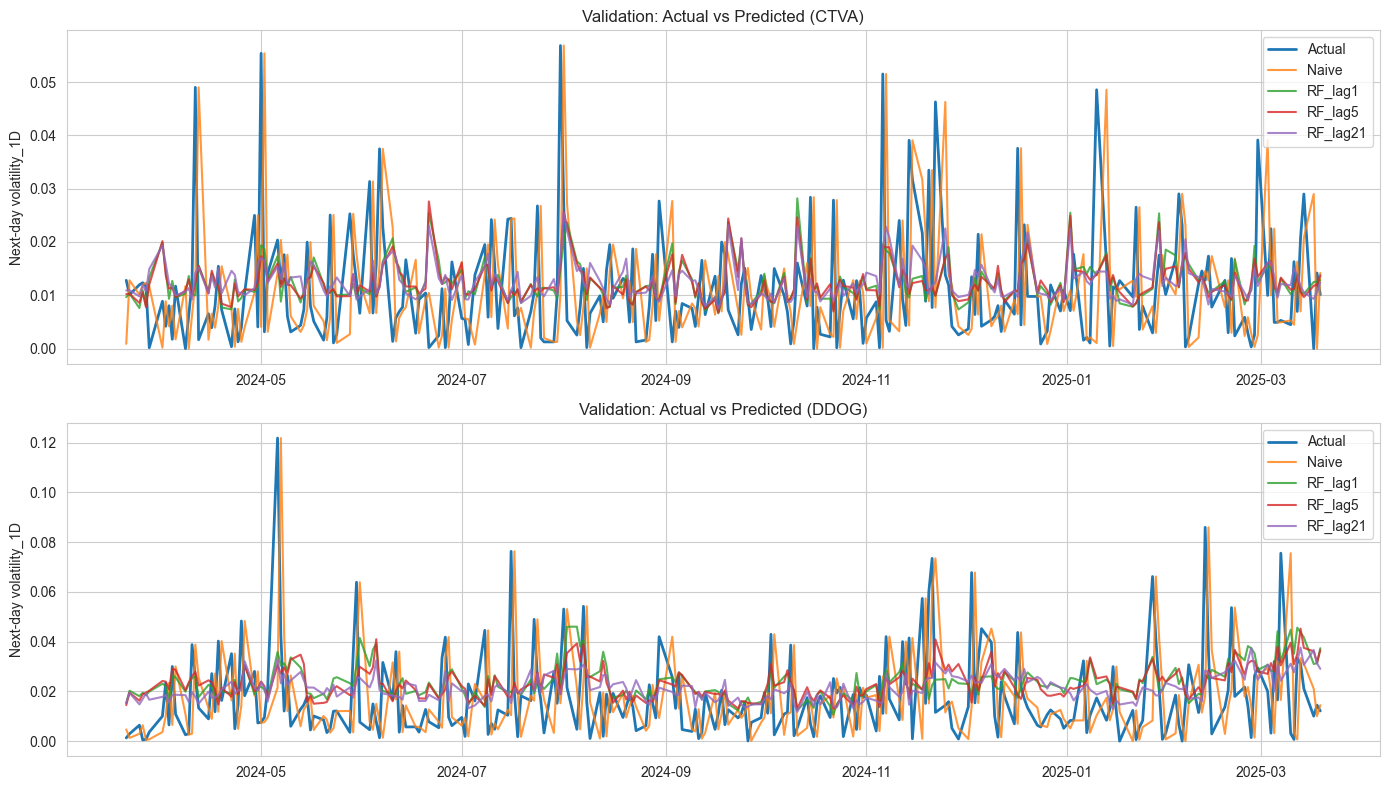

In [16]:
fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = validation_predictions_df[validation_predictions_df["Symbol"] == symbol]
    ax.plot(p["Date"], p["actual"], label="Actual", linewidth=2)
    ax.plot(p["Date"], p["pred_naive"], label="Naive", alpha=0.8)
    ax.plot(p["Date"], p["pred_RF_lag1"], label="RF_lag1", alpha=0.8)
    ax.plot(p["Date"], p["pred_RF_lag5"], label="RF_lag5", alpha=0.8)
    ax.plot(p["Date"], p["pred_RF_lag21"], label="RF_lag21", alpha=0.8)
    ax.set_title(f"Validation: Actual vs Predicted ({symbol})")
    ax.set_ylabel("Next-day volatility_1D")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Validation Plots: Rolling Absolute Error

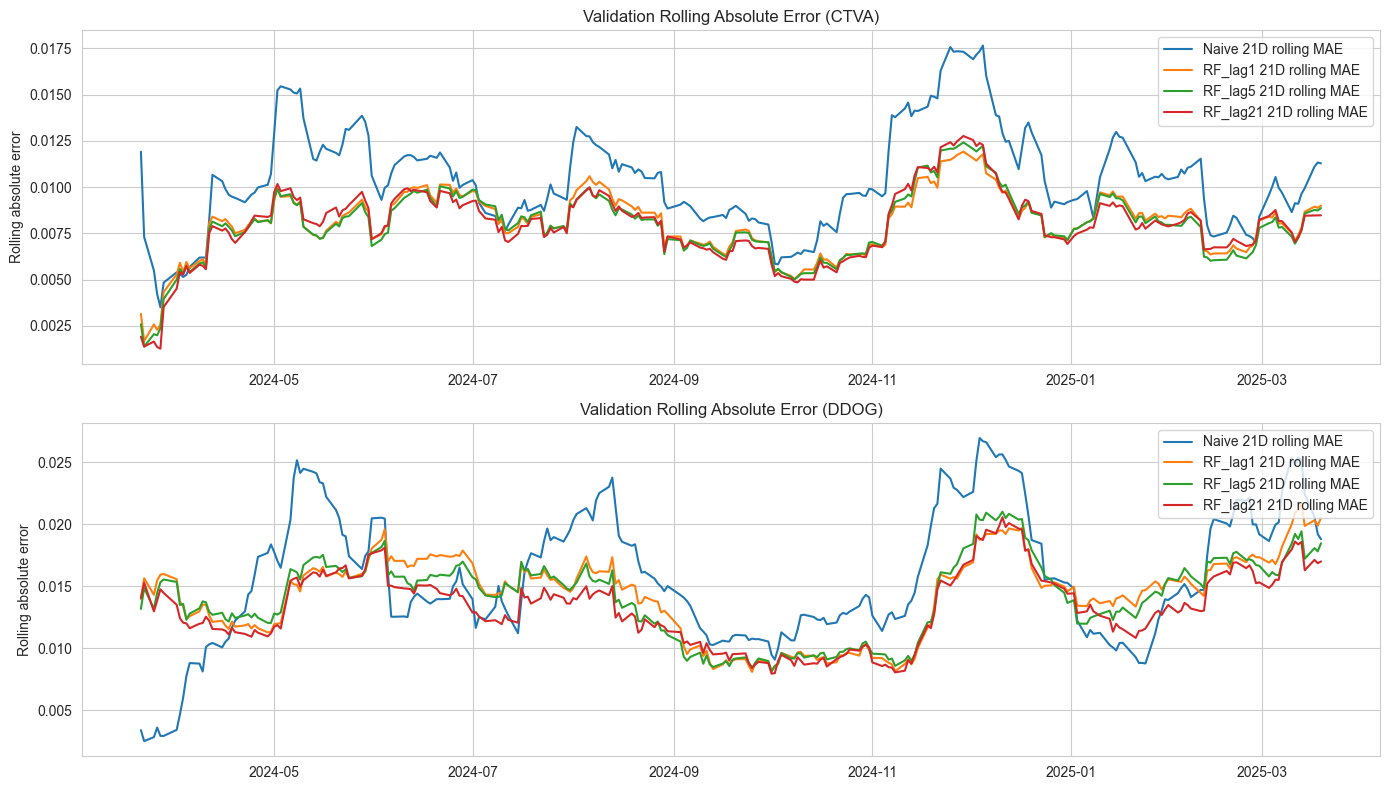

In [17]:
rolling_window = 21

fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = validation_predictions_df[validation_predictions_df["Symbol"] == symbol].copy()

    p["abs_err_naive"] = np.abs(p["actual"] - p["pred_naive"])
    p["abs_err_RF_lag1"] = np.abs(p["actual"] - p["pred_RF_lag1"])
    p["abs_err_RF_lag5"] = np.abs(p["actual"] - p["pred_RF_lag5"])
    p["abs_err_RF_lag21"] = np.abs(p["actual"] - p["pred_RF_lag21"])

    p["roll_abs_err_naive"] = p["abs_err_naive"].rolling(rolling_window, min_periods=1).mean()
    p["roll_abs_err_RF_lag1"] = p["abs_err_RF_lag1"].rolling(rolling_window, min_periods=1).mean()
    p["roll_abs_err_RF_lag5"] = p["abs_err_RF_lag5"].rolling(rolling_window, min_periods=1).mean()
    p["roll_abs_err_RF_lag21"] = p["abs_err_RF_lag21"].rolling(rolling_window, min_periods=1).mean()

    ax.plot(p["Date"], p["roll_abs_err_naive"], label=f"Naive {rolling_window}D rolling MAE")
    ax.plot(p["Date"], p["roll_abs_err_RF_lag1"], label=f"RF_lag1 {rolling_window}D rolling MAE")
    ax.plot(p["Date"], p["roll_abs_err_RF_lag5"], label=f"RF_lag5 {rolling_window}D rolling MAE")
    ax.plot(p["Date"], p["roll_abs_err_RF_lag21"], label=f"RF_lag21 {rolling_window}D rolling MAE")
    ax.set_title(f"Validation Rolling Absolute Error ({symbol})")
    ax.set_ylabel("Rolling absolute error")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Retrain on Train+Validation and Forecast Unseen

Rules applied:
- Fit new scalers on train+validation (per stock and lag model).
- Retrain fresh models on train+validation.
- Forecast unseen sequentially one day ahead.
- Do not refit models daily.

In [18]:
trainval_raw = df[(df["Date"] >= data_start) & (df["Date"] <= val_end)].copy()
unseen_raw = unseen_reference_small[
    (unseen_reference_small["Date"] >= unseen_start) & (unseen_reference_small["Date"] <= unseen_end)
].copy()

print("trainval_raw shape:", trainval_raw.shape)
print("unseen_raw shape (from unseen_path):", unseen_raw.shape)

trainval_raw shape: (2010, 10)
unseen_raw shape (from unseen_path): (502, 10)


In [19]:
trainval_features = create_engineered_features(
    trainval_raw,
    include_today=include_today,
    use_log_volatility=use_log_volatility,
    n_lags=n_lags_max
)
trainval_model_df = trainval_features.dropna(subset=required_for_full_lag).copy()

print("trainval_features shape:", trainval_features.shape)
print("trainval_model_df shape:", trainval_model_df.shape)
display(trainval_model_df.head(3))

trainval_features shape: (2010, 41)
trainval_model_df shape: (1964, 41)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,volatility_1D_lag13,volatility_1D_lag14,volatility_1D_lag15,volatility_1D_lag16,volatility_1D_lag17,volatility_1D_lag18,volatility_1D_lag19,volatility_1D_lag20,volatility_1D_lag21,target_next_volatility_1D
22,2021-04-22,45.765937,46.267713,45.150547,45.519783,3445600.0,CTVA,Corteva,Materials,0.0009,...,0.006398,0.002571,0.006841,0.017528,0.002926,0.023868,0.012693,0.007388,0.031135,0.011374
23,2021-04-23,45.529254,46.310325,45.396710,46.040501,2501300.0,CTVA,Corteva,Materials,0.0009,...,0.014771,0.006398,0.002571,0.006841,0.017528,0.002926,0.023868,0.012693,0.007388,0.004923
24,2021-04-26,46.125694,46.712678,46.054687,46.267704,1890000.0,CTVA,Corteva,Materials,0.0009,...,0.020955,0.014771,0.006398,0.002571,0.006841,0.017528,0.002926,0.023868,0.012693,0.005917


In [20]:
# Build unseen features with trailing history so earliest unseen rows have valid windows/lags
history_tail_rows = 80
unseen_features_parts = []

for symbol in symbols_to_model:
    hist_symbol = trainval_raw[trainval_raw["Symbol"] == symbol].sort_values("Date").tail(history_tail_rows)
    unseen_symbol = unseen_raw[unseen_raw["Symbol"] == symbol].sort_values("Date")

    combined_symbol = pd.concat([hist_symbol, unseen_symbol], axis=0).sort_values("Date").copy()
    combined_symbol["Symbol"] = symbol

    engineered_symbol = create_engineered_features(
        combined_symbol,
        include_today=include_today,
        use_log_volatility=use_log_volatility,
        n_lags=n_lags_max
    )

    engineered_symbol = engineered_symbol[
        (engineered_symbol["Date"] >= unseen_start) & (engineered_symbol["Date"] <= unseen_end)
    ].copy()
    unseen_features_parts.append(engineered_symbol)

unseen_features = pd.concat(unseen_features_parts, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)
unseen_model_df = unseen_features.dropna(subset=required_for_full_lag).copy()

print("unseen_features shape:", unseen_features.shape)
print("unseen_model_df shape:", unseen_model_df.shape)
display(unseen_model_df.head(3))

unseen_features shape: (502, 41)
unseen_model_df shape: (500, 41)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,volatility_1D_lag13,volatility_1D_lag14,volatility_1D_lag15,volatility_1D_lag16,volatility_1D_lag17,volatility_1D_lag18,volatility_1D_lag19,volatility_1D_lag20,volatility_1D_lag21,target_next_volatility_1D
0,2025-03-21,60.942673,61.338788,60.561408,61.120926,6880500.0,CTVA,Corteva,Materials,0.0009,...,0.009984,0.039125,0.002544,0.000318,0.002862,0.005892,0.002393,0.016905,0.002981,0.005655
1,2025-03-24,61.992384,61.992384,61.051608,61.467529,2117800.0,CTVA,Corteva,Materials,0.0009,...,0.022488,0.009984,0.039125,0.002544,0.000318,0.002862,0.005892,0.002393,0.016905,0.003551
2,2025-03-25,61.477435,61.744811,60.962482,61.249664,2565200.0,CTVA,Corteva,Materials,0.0009,...,0.004917,0.022488,0.009984,0.039125,0.002544,0.000318,0.002862,0.005892,0.002393,0.013649


In [21]:
unseen_records = []
unseen_predictions = []
fitted_scalers_unseen = {}
fitted_models_unseen = {}

for symbol in symbols_to_model:
    print(f"\n--- Retrain + unseen forecasting for {symbol} ---")

    trainval_s = trainval_model_df[trainval_model_df["Symbol"] == symbol].sort_values("Date").copy()
    unseen_s = unseen_model_df[unseen_model_df["Symbol"] == symbol].sort_values("Date").copy()

    print("Train+Val rows:", len(trainval_s), "| Unseen rows:", len(unseen_s))

    y_tv = trainval_s[target_col].values
    y_unseen = unseen_s[target_col].values

    pred_df = unseen_s[["Date", "Symbol", target_col, "volatility_1D"]].copy()
    pred_df.rename(columns={target_col: "actual"}, inplace=True)

    naive_preds = unseen_s["volatility_1D"].values
    pred_df["pred_naive"] = naive_preds

    naive_metrics = compute_metrics(y_unseen, naive_preds)
    unseen_records.append({
        "Stage": "Unseen",
        "Symbol": symbol,
        "Model": "Naive(today_vol)",
        **naive_metrics
    })

    for lag_n in lag_options:
        model_name = f"RF_lag{lag_n}"
        feature_cols = get_feature_cols_for_lag(lag_n)

        X_tv = trainval_s[feature_cols].values
        X_unseen = unseen_s[feature_cols].values

        scaler_tv = StandardScaler()
        X_tv_scaled = scaler_tv.fit_transform(X_tv)

        model_tv = RandomForestRegressor(
            n_estimators=rf_n_estimators,
            max_depth=rf_max_depth,
            min_samples_leaf=rf_min_samples_leaf,
            random_state=SEED,
            n_jobs=-1
        )
        model_tv.fit(X_tv_scaled, y_tv)

        # Sequential one-step-ahead inference without refitting
        preds = []
        for i in range(len(unseen_s)):
            x_i = X_unseen[i].reshape(1, -1)
            x_i_scaled = scaler_tv.transform(x_i)
            pred_i = model_tv.predict(x_i_scaled).ravel()[0]
            preds.append(pred_i)

        preds = np.maximum(np.array(preds), 0.0)
        pred_df[f"pred_{model_name}"] = preds

        model_metrics = compute_metrics(y_unseen, preds)
        unseen_records.append({
            "Stage": "Unseen",
            "Symbol": symbol,
            "Model": model_name,
            **model_metrics
        })

        fitted_scalers_unseen[(symbol, lag_n)] = scaler_tv
        fitted_models_unseen[(symbol, lag_n)] = model_tv

    unseen_predictions.append(pred_df)


--- Retrain + unseen forecasting for CTVA ---
Train+Val rows: 982 | Unseen rows: 250



--- Retrain + unseen forecasting for DDOG ---
Train+Val rows: 982 | Unseen rows: 250


In [22]:
unseen_metrics_df = pd.DataFrame(unseen_records)
unseen_predictions_df = (
    pd.concat(unseen_predictions, axis=0)
    .sort_values(["Symbol", "Date"])
    .reset_index(drop=True)
)

print("Unseen metrics:")
display(unseen_metrics_df.sort_values(["Symbol", "Model"]))

print("Unseen RMSE pivot:")
display(
    unseen_metrics_df.pivot_table(
        index=["Symbol"],
        columns="Model",
        values="RMSE"
    )
)

print("Unseen predictions head:")
display(unseen_predictions_df.head(5))

Unseen metrics:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
0,Unseen,CTVA,Naive(today_vol),0.016783,0.010460,0.000282,0.070118,92.253878
1,Unseen,CTVA,RF_lag1,0.012708,0.008560,0.000162,0.100885,77.510826
3,Unseen,CTVA,RF_lag21,0.012735,0.008645,0.000162,0.054622,78.176719
2,Unseen,CTVA,RF_lag5,0.012734,0.008482,0.000162,0.075950,76.874345
4,Unseen,DDOG,Naive(today_vol),0.034946,0.021325,0.001221,0.049131,90.301064
5,Unseen,DDOG,RF_lag1,0.026082,0.017529,0.000680,0.058335,78.151862
7,Unseen,DDOG,RF_lag21,0.025765,0.017167,0.000664,0.069868,77.496971
6,Unseen,DDOG,RF_lag5,0.026167,0.017534,0.000685,0.036440,78.099744


Unseen RMSE pivot:


Model,Naive(today_vol),RF_lag1,RF_lag21,RF_lag5
Symbol,,,,
CTVA,0.016783,0.012708,0.012735,0.012734
DDOG,0.034946,0.026082,0.025765,0.026167


Unseen predictions head:


,Date,Symbol,actual,volatility_1D,pred_naive,pred_RF_lag1,pred_RF_lag5,pred_RF_lag21
0,2025-03-21,CTVA,0.005655,0.001781,0.001781,0.014312,0.016060,0.017632
1,2025-03-24,CTVA,0.003551,0.005655,0.005655,0.009131,0.010002,0.010823
2,2025-03-25,CTVA,0.013649,0.003551,0.003551,0.009137,0.008724,0.008539
3,2025-03-26,CTVA,0.004155,0.013649,0.013649,0.010993,0.010151,0.010073
4,2025-03-27,CTVA,0.022349,0.004155,0.004155,0.012658,0.012519,0.013279


## Unseen Plots: Actual vs Predicted

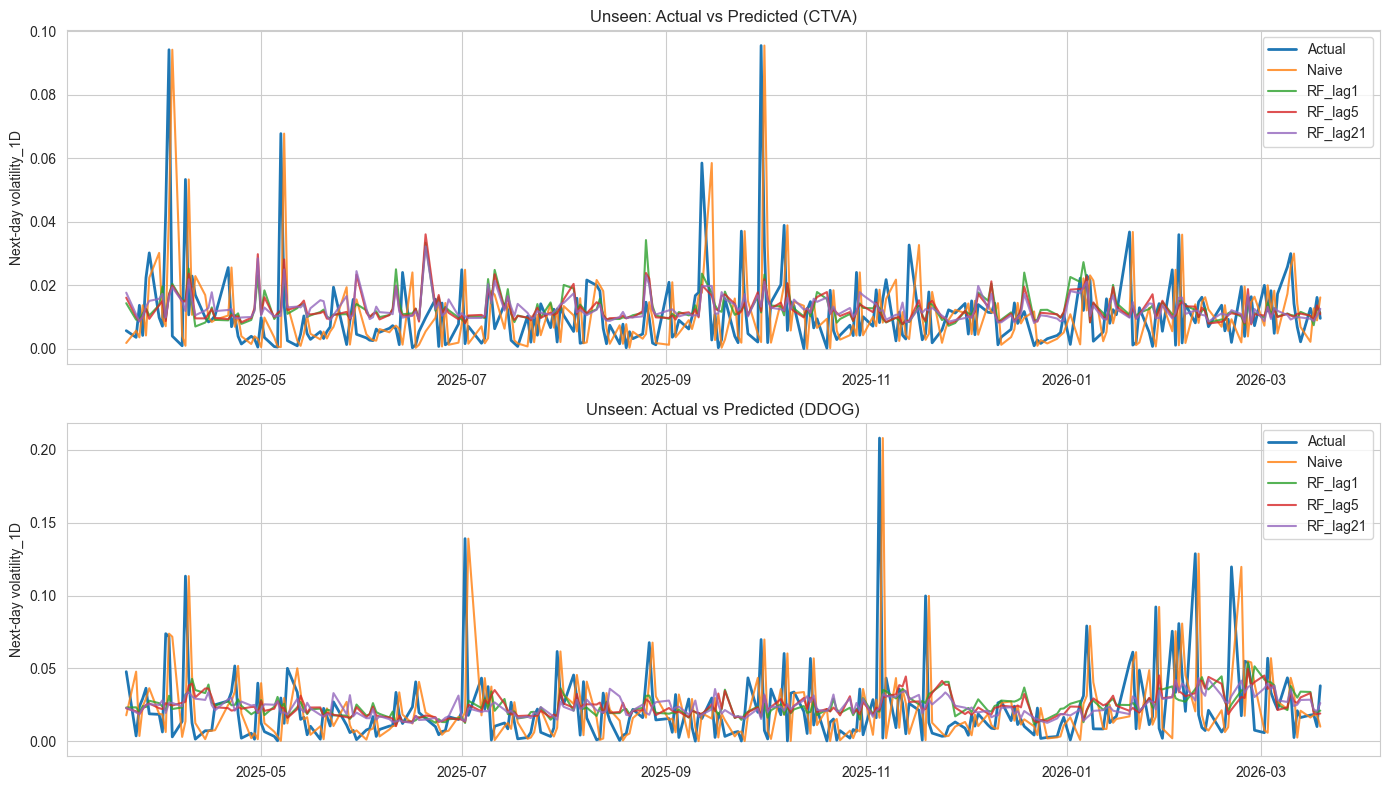

In [23]:
fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = unseen_predictions_df[unseen_predictions_df["Symbol"] == symbol]
    ax.plot(p["Date"], p["actual"], label="Actual", linewidth=2)
    ax.plot(p["Date"], p["pred_naive"], label="Naive", alpha=0.8)
    ax.plot(p["Date"], p["pred_RF_lag1"], label="RF_lag1", alpha=0.8)
    ax.plot(p["Date"], p["pred_RF_lag5"], label="RF_lag5", alpha=0.8)
    ax.plot(p["Date"], p["pred_RF_lag21"], label="RF_lag21", alpha=0.8)
    ax.set_title(f"Unseen: Actual vs Predicted ({symbol})")
    ax.set_ylabel("Next-day volatility_1D")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Unseen Plots: Rolling Absolute Error

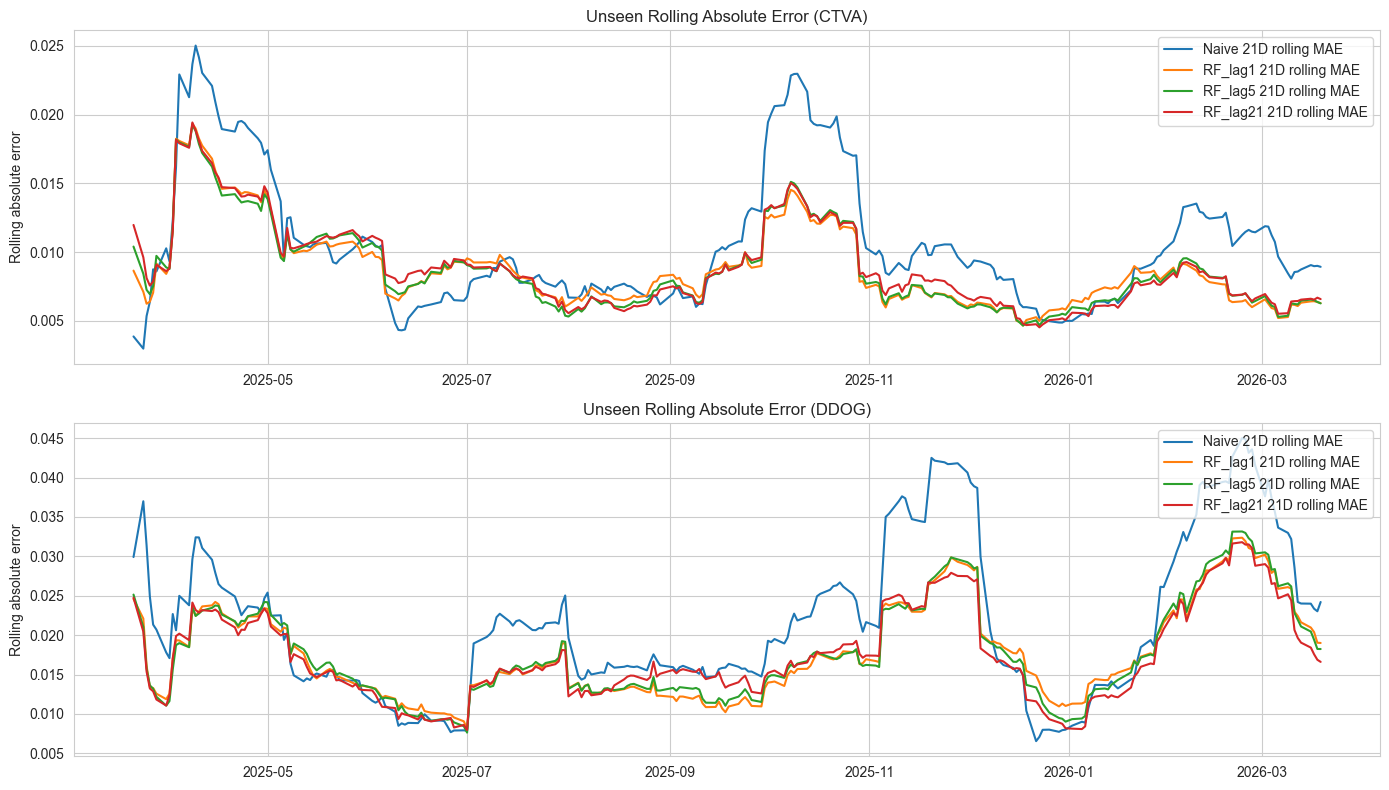

In [24]:
rolling_window = 21

fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = unseen_predictions_df[unseen_predictions_df["Symbol"] == symbol].copy()

    p["abs_err_naive"] = np.abs(p["actual"] - p["pred_naive"])
    p["abs_err_RF_lag1"] = np.abs(p["actual"] - p["pred_RF_lag1"])
    p["abs_err_RF_lag5"] = np.abs(p["actual"] - p["pred_RF_lag5"])
    p["abs_err_RF_lag21"] = np.abs(p["actual"] - p["pred_RF_lag21"])

    p["roll_abs_err_naive"] = p["abs_err_naive"].rolling(rolling_window, min_periods=1).mean()
    p["roll_abs_err_RF_lag1"] = p["abs_err_RF_lag1"].rolling(rolling_window, min_periods=1).mean()
    p["roll_abs_err_RF_lag5"] = p["abs_err_RF_lag5"].rolling(rolling_window, min_periods=1).mean()
    p["roll_abs_err_RF_lag21"] = p["abs_err_RF_lag21"].rolling(rolling_window, min_periods=1).mean()

    ax.plot(p["Date"], p["roll_abs_err_naive"], label=f"Naive {rolling_window}D rolling MAE")
    ax.plot(p["Date"], p["roll_abs_err_RF_lag1"], label=f"RF_lag1 {rolling_window}D rolling MAE")
    ax.plot(p["Date"], p["roll_abs_err_RF_lag5"], label=f"RF_lag5 {rolling_window}D rolling MAE")
    ax.plot(p["Date"], p["roll_abs_err_RF_lag21"], label=f"RF_lag21 {rolling_window}D rolling MAE")
    ax.set_title(f"Unseen Rolling Absolute Error ({symbol})")
    ax.set_ylabel("Rolling absolute error")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Metric Summary Tables

In [25]:
all_metrics_df = pd.concat([validation_metrics_df, unseen_metrics_df], axis=0).reset_index(drop=True)
all_metrics_df = all_metrics_df.sort_values(["Stage", "Symbol", "Model"]).reset_index(drop=True)

print("All metrics long-form:")
display(all_metrics_df)

print("RMSE by stage, stock, and model:")
display(
    all_metrics_df.pivot_table(
        index=["Stage", "Symbol"],
        columns="Model",
        values="RMSE"
    )
)

All metrics long-form:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
0,Unseen,CTVA,Naive(today_vol),0.016783,0.010460,0.000282,0.070118,92.253878
1,Unseen,CTVA,RF_lag1,0.012708,0.008560,0.000162,0.100885,77.510826
2,Unseen,CTVA,RF_lag21,0.012735,0.008645,0.000162,0.054622,78.176719
3,Unseen,CTVA,RF_lag5,0.012734,0.008482,0.000162,0.075950,76.874345
4,Unseen,DDOG,Naive(today_vol),0.034946,0.021325,0.001221,0.049131,90.301064
5,Unseen,DDOG,RF_lag1,0.026082,0.017529,0.000680,0.058335,78.151862
6,Unseen,DDOG,RF_lag21,0.025765,0.017167,0.000664,0.069868,77.496971
7,Unseen,DDOG,RF_lag5,0.026167,0.017534,0.000685,0.036440,78.099744
8,Validation,CTVA,Naive(today_vol),0.014867,0.010580,0.000221,-0.032664,95.464999
9,Validation,CTVA,RF_lag1,0.010906,0.008221,0.000119,0.033338,74.379906


RMSE by stage, stock, and model:


Model              Naive(today_vol)   RF_lag1  RF_lag21   RF_lag5
Stage      Symbol                                                
Unseen     CTVA            0.016783  0.012708  0.012735  0.012734
           DDOG            0.034946  0.026082  0.025765  0.026167
Validation CTVA            0.014867  0.010906  0.010634  0.010796
           DDOG            0.022630  0.018310  0.017221  0.018196

## Best Lag Model by Stock and Stage

In [26]:
rf_only = all_metrics_df[all_metrics_df["Model"].isin([f"RF_lag{x}" for x in lag_options])].copy()
best_by_rmse = (
    rf_only.sort_values(["Stage", "Symbol", "RMSE"])
    .groupby(["Stage", "Symbol"], as_index=False)
    .first()
)

print("Best RF model by RMSE:")
display(best_by_rmse[["Stage", "Symbol", "Model", "RMSE", "MAE", "MSE", "Corr", "sMAPE"]])

Best RF model by RMSE:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
0,Unseen,CTVA,RF_lag1,0.012708,0.008560,0.000162,0.100885,77.510826
1,Unseen,DDOG,RF_lag21,0.025765,0.017167,0.000664,0.069868,77.496971
2,Validation,CTVA,RF_lag21,0.010634,0.008120,0.000113,0.101977,74.142010
3,Validation,DDOG,RF_lag21,0.017221,0.013479,0.000297,0.192938,75.281976


## Feature Importance (Unseen-Retrained Models)

In [27]:
fi_rows = []
for symbol in symbols_to_model:
    for lag_n in lag_options:
        model = fitted_models_unseen[(symbol, lag_n)]
        cols = get_feature_cols_for_lag(lag_n)
        fi = pd.Series(model.feature_importances_, index=cols).sort_values(ascending=False).head(10)
        for feat_name, feat_val in fi.items():
            fi_rows.append({
                "Symbol": symbol,
                "Model": f"RF_lag{lag_n}",
                "Feature": feat_name,
                "Importance": feat_val
            })

fi_df = pd.DataFrame(fi_rows).sort_values(["Symbol", "Model", "Importance"], ascending=[True, True, False])
print("Top feature importances:")
display(fi_df.head(30))

Top feature importances:


,Symbol,Model,Feature,Importance
0,CTVA,RF_lag1,volume_change_5D,0.167032
1,CTVA,RF_lag1,volatility_1D_lag1,0.122695
2,CTVA,RF_lag1,volume_change_21D,0.120193
3,CTVA,RF_lag1,volatility_21D,0.097195
4,CTVA,RF_lag1,log_return_5D,0.092964
5,CTVA,RF_lag1,volume_change_1D,0.092682
6,CTVA,RF_lag1,volatility_1D,0.084219
7,CTVA,RF_lag1,volatility_5D,0.080014
8,CTVA,RF_lag1,log_return_1D,0.079573
9,CTVA,RF_lag1,log_return_21D,0.063433


## Final Data Checks and Samples

In [28]:
print("Train rows by stock:")
display(train_df.groupby("Symbol").size().rename("rows").reset_index())

print("Validation rows by stock:")
display(val_df.groupby("Symbol").size().rename("rows").reset_index())

print("Unseen rows by stock (model-ready):")
display(unseen_model_df.groupby("Symbol").size().rename("rows").reset_index())

Train rows by stock:


,Symbol,rows
0,CTVA,733
1,DDOG,733


Validation rows by stock:


,Symbol,rows
0,CTVA,249
1,DDOG,249


Unseen rows by stock (model-ready):


,Symbol,rows
0,CTVA,250
1,DDOG,250


In [29]:
print("Validation prediction sample:")
display(validation_predictions_df.groupby("Symbol").head(3))

print("Unseen prediction sample:")
display(unseen_predictions_df.groupby("Symbol").head(3))

Validation prediction sample:


,Date,Symbol,actual,volatility_1D,pred_naive,pred_RF_lag1,pred_RF_lag5,pred_RF_lag21
0,2024-03-21,CTVA,0.012810,0.000897,0.000897,0.009664,0.010226,0.010900
1,2024-03-22,CTVA,0.010118,0.012810,0.012810,0.010333,0.010292,0.010962
2,2024-03-25,CTVA,0.011972,0.010118,0.010118,0.007609,0.008587,0.009786
249,2024-03-21,DDOG,0.001301,0.004710,0.004710,0.015273,0.014484,0.015372
250,2024-03-22,DDOG,0.002931,0.001301,0.001301,0.020269,0.019489,0.019453
251,2024-03-25,DDOG,0.006420,0.002931,0.002931,0.018080,0.016273,0.014784


Unseen prediction sample:


,Date,Symbol,actual,volatility_1D,pred_naive,pred_RF_lag1,pred_RF_lag5,pred_RF_lag21
0,2025-03-21,CTVA,0.005655,0.001781,0.001781,0.014312,0.016060,0.017632
1,2025-03-24,CTVA,0.003551,0.005655,0.005655,0.009131,0.010002,0.010823
2,2025-03-25,CTVA,0.013649,0.003551,0.003551,0.009137,0.008724,0.008539
250,2025-03-21,DDOG,0.047779,0.017868,0.017868,0.023180,0.022631,0.023027
251,2025-03-24,DDOG,0.003715,0.047779,0.047779,0.023318,0.020647,0.019866
252,2025-03-25,DDOG,0.023886,0.003715,0.003715,0.019749,0.018678,0.018640


## Notes

- Separate models are trained per stock (`CTVA`, `DDOG`).
- Target is next-day `volatility_1D`.
- Three Random Forest lag variants are compared (`lag1`, `lag5`, `lag21`).
- Validation is used for model assessment/design.
- Final unseen forecasting is sequential one-step-ahead without daily model refits.